--- 10 dòng đầu tiên của tập dữ liệu Titanic ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6              

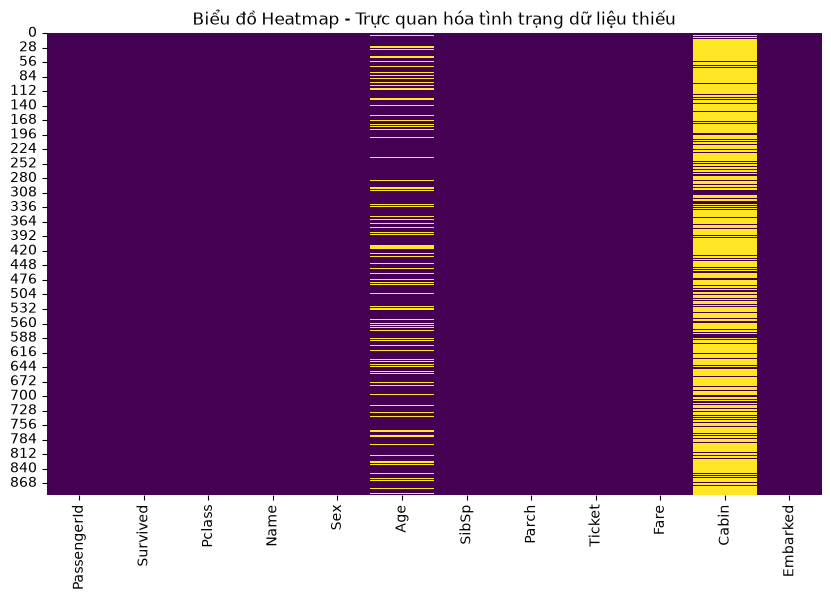


> Nhận xét về tình trạng thiếu dữ liệu:
> * Age (Tuổi): Thiếu một lượng dữ liệu vừa phải (khoảng 20%). Các vạch vàng rải rác đều trên heatmap. Cần điền khuyết dựa trên các mối quan hệ nhóm tương quan.
> * Cabin (Số phòng): Thiếu cực kỳ nghiêm trọng (lên tới hơn 70%). Không thể dùng giá trị thống kê thông thường để bù đắp mà cần nhóm lại thành một danh mục đặc biệt.
> * Embarked (Cảng lên tàu): Thiếu rất ít dữ liệu (chỉ lác đác vài trường hợp), có thể lấp đầy nhanh chóng bằng giá trị xuất hiện nhiều nhất (Mode).

--------------------------------------------------
--- Kết quả sau khi tách cột Name ---
   firstName                                   secondName
0     Braund                              Mr. Owen Harris
1    Cumings   Mrs. John Bradley (Florence Briggs Thayer)
2  Heikkinen                                  Miss. Laina
3   Futrelle           Mrs. Jacques Heath (Lily May Peel)
4      Allen                            Mr. William Henry
--------------------------------------------

C:\Users\Admin\AppData\Local\Temp\ipykernel_8756\3154221178.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=titanic_df, palette='Set2')


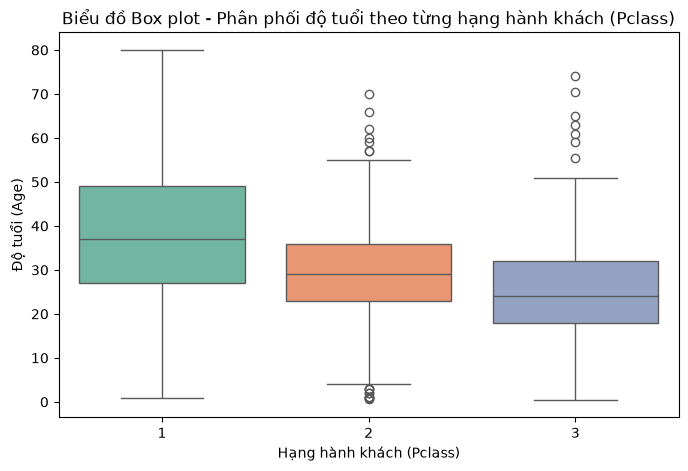


> Nhận xét & Quyết định cách thay thế:
> Nhìn vào biểu đồ Box plot, tuổi trung vị giữa các nhóm hạng vé có sự chênh lệch rõ ràng: hành khách Hạng 1 có số tuổi trung bình cao nhất (khoảng 37-38 tuổi), tiếp đến là Hạng 2 (khoảng 29 tuổi) và trẻ nhất là nhóm Hạng 3 (khoảng 24-25 tuổi).
> Quyết định: Thay thế các giá trị tuổi bị thiếu bằng giá trị tuổi trung bình theo từng nhóm hạng hành khách (Pclass) để đảm bảo tính logic và chính xác cao hơn.

Tuổi trung bình chi tiết theo từng hạng vé:
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


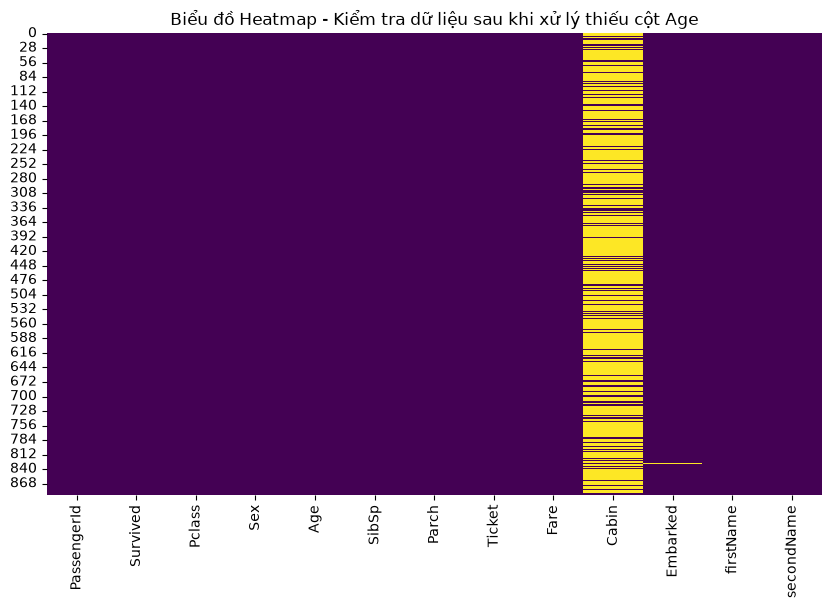

--------------------------------------------------
--- Số lượng phân bổ theo nhóm tuổi (Agegroup) ---
Agegroup
Adult    730
Teen      70
Kid       69
Older     22
Name: count, dtype: int64
--------------------------------------------------
--- Top danh xưng xã hội phổ biến trích xuất được ---
namePrefix
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Name: count, dtype: int64
--------------------------------------------------
--- Kiểm tra dữ liệu đặc trưng gia đình mới tạo ---
   familySize  Alone
0           2      0
1           2      0
2           1      1
3           2      0
4           1      1
--------------------------------------------------
--- Danh sách phân loại Cabin ---
typeCabin
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64
--------------------------------------------------
XỬ LÝ HOÀN TẤT! Kích thước file dữ liệu sạch được lưu trữ: (891, 18)


In [2]:
# ==========================================
# LAB 4 - PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Bước 1: Viết hàm load_data() để tải dữ liệu lên ứng dụng ---
def load_data():
    # Tải dữ liệu trực tiếp từ file titanic_disaster.csv được cung cấp
    df = pd.read_csv('titanic_disaster.csv')
    return df

# Khởi tạo dataframe
titanic_df = load_data()
print("--- 10 dòng đầu tiên của tập dữ liệu Titanic ---")
print(titanic_df.head(10))
print("-" * 50)


# --- Bước 2: Thống kê dữ liệu thiếu trên các biến số và trực quan hóa bằng Heatmap ---
print("--- Thống kê số lượng dữ liệu thiếu trên các biến số ---")
print(titanic_df.isnull().sum())

plt.figure(figsize=(10, 6))
sns.heatmap(titanic_df.isnull(), cbar=False, cmap='viridis')
plt.title('Biểu đồ Heatmap - Trực quan hóa tình trạng dữ liệu thiếu')
plt.show()

print("""
> Nhận xét về tình trạng thiếu dữ liệu:
> * Age (Tuổi): Thiếu một lượng dữ liệu vừa phải (khoảng 20%). Các vạch vàng rải rác đều trên heatmap. Cần điền khuyết dựa trên các mối quan hệ nhóm tương quan.
> * Cabin (Số phòng): Thiếu cực kỳ nghiêm trọng (lên tới hơn 70%). Không thể dùng giá trị thống kê thông thường để bù đắp mà cần nhóm lại thành một danh mục đặc biệt.
> * Embarked (Cảng lên tàu): Thiếu rất ít dữ liệu (chỉ lác đác vài trường hợp), có thể lấp đầy nhanh chóng bằng giá trị xuất hiện nhiều nhất (Mode).
""")
print("-" * 50)


# --- Bước 3: Xử lý cột Name, tách ra làm 2 cột: firstName và secondName (Xóa cột Name) ---
titanic_df[['firstName', 'secondName']] = titanic_df['Name'].str.split(',', n=1, expand=True)
titanic_df.drop(columns=['Name'], inplace=True)

print("--- Kết quả sau khi tách cột Name ---")
print(titanic_df[['firstName', 'secondName']].head())
print("-" * 50)


# --- Bước 4: Xử lý rút gọn kích thước dữ liệu trên cột Sex (male -> M, female -> F) ---
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 'M', 'female': 'F'})

print("--- Thống kê tần suất sau khi chuẩn hóa cột Sex ---")
print(titanic_df['Sex'].value_counts())
print("-" * 50)


# --- Bước 5: Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi ---
# a. Sử dụng Seaborn để vẽ biểu đồ Box plot trực quan dữ liệu để xác định phân phối tuổi trên từng hạng hành khách (Pclass)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', data=titanic_df, palette='Set2')
plt.title('Biểu đồ Box plot - Phân phối độ tuổi theo từng hạng hành khách (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Độ tuổi (Age)')
plt.show()

print("""
> Nhận xét & Quyết định cách thay thế:
> Nhìn vào biểu đồ Box plot, tuổi trung vị giữa các nhóm hạng vé có sự chênh lệch rõ ràng: hành khách Hạng 1 có số tuổi trung bình cao nhất (khoảng 37-38 tuổi), tiếp đến là Hạng 2 (khoảng 29 tuổi) và trẻ nhất là nhóm Hạng 3 (khoảng 24-25 tuổi).
> Quyết định: Thay thế các giá trị tuổi bị thiếu bằng giá trị tuổi trung bình theo từng nhóm hạng hành khách (Pclass) để đảm bảo tính logic và chính xác cao hơn.
""")

# b. Tiến hành thay thế giá trị Age bị thiếu và trực quan lại bằng Heatmap
age_mean_by_pclass = titanic_df.groupby('Pclass')['Age'].mean()
print("Tuổi trung bình chi tiết theo từng hạng vé:")
print(age_mean_by_pclass)

titanic_df['Age'] = titanic_df.apply(
    lambda row: age_mean_by_pclass[row['Pclass']] if pd.isnull(row['Age']) else row['Age'], 
    axis=1
)

plt.figure(figsize=(10, 6))
sns.heatmap(titanic_df.isnull(), cbar=False, cmap='viridis')
plt.title('Biểu đồ Heatmap - Kiểm tra dữ liệu sau khi xử lý thiếu cột Age')
plt.show()
print("-" * 50)


# --- Bước 6: Xây dựng biến số Agegroup có thang đo thứ tự ---
def classify_age_group(age):
    if age <= 12:
        return 'Kid'
    elif age <= 18:
        return 'Teen'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Older'

titanic_df['Agegroup'] = titanic_df['Age'].apply(classify_age_group)

print("--- Số lượng phân bổ theo nhóm tuổi (Agegroup) ---")
print(titanic_df['Agegroup'].value_counts())
print("-" * 50)


# --- Bước 7: Tiến hành thêm đặc trưng về danh xưng (namePrefix) ---
titanic_df['namePrefix'] = titanic_df['secondName'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("--- Top danh xưng xã hội phổ biến trích xuất được ---")
print(titanic_df['namePrefix'].value_counts().head())
print("-" * 50)


# --- Bước 8 & 9: Khai thác thông tin familySize và tạo đặc trưng Alone ---
titanic_df['familySize'] = 1 + titanic_df['SibSp'] + titanic_df['Parch']
titanic_df['Alone'] = titanic_df['familySize'].apply(lambda size: 1 if size == 1 else 0)

print("--- Kiểm tra dữ liệu đặc trưng gia đình mới tạo ---")
print(titanic_df[['familySize', 'Alone']].head())
print("-" * 50)


# --- Bước 10: Tiến hành tách loại cabin (typeCabin) và xử lý dữ liệu thiếu ---
titanic_df['typeCabin'] = titanic_df['Cabin'].fillna('Unknown').astype(str).str[0]

print("--- Danh sách phân loại Cabin ---")
print(titanic_df['typeCabin'].value_counts())
print("-" * 50)


# --- Bước 11: Loại bỏ dữ liệu trùng lặp thừa, reindex và lưu trữ dữ liệu thành công ---
titanic_df.drop_duplicates(subset=['PassengerId'], keep='first', inplace=True)
titanic_df.reset_index(drop=True, inplace=True)

# Lưu trữ thành file csv sạch theo yêu cầu
titanic_df.to_csv('patient_heart_rate_clean.csv', index=False)
print(f"XỬ LÝ HOÀN TẤT! Kích thước file dữ liệu sạch được lưu trữ: {titanic_df.shape}")

--- BẮT ĐẦU QUY TRÌNH KHAI THÁC THÔNG TIN HỮU ÍCH (EDA) ---


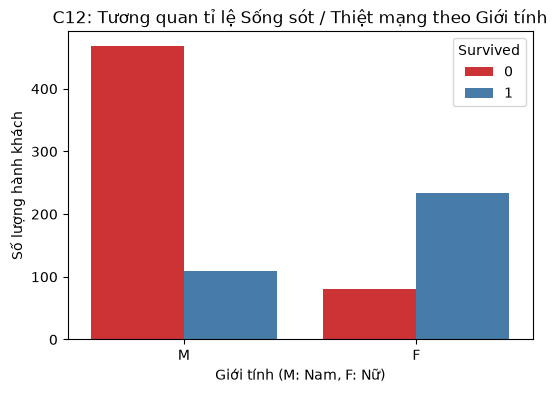


> Nhận xét Câu 12: 
  Biểu đồ thể hiện rõ rệt sự phân hóa cơ hội sống sót qua giới tính. Tỷ lệ sống sót của Nữ giới (F) vượt trội hoàn toàn 
  so với tỷ lệ thiệt mạng. Ngược lại, đại đa số Nam giới (M) đều không thể sống sót. Giới tính chắc chắn là biến số 
  có trọng số hàng đầu trong mô hình dự đoán hành khách sống sót.

--------------------------------------------------


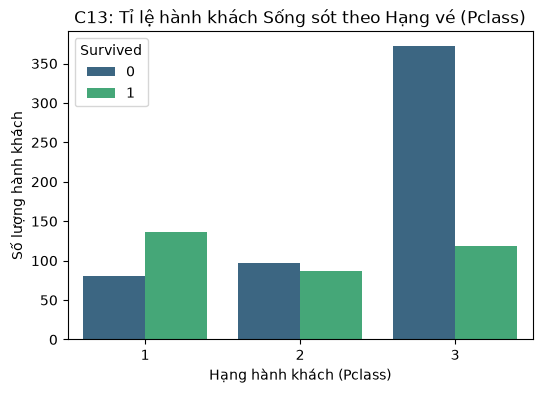


> Nhận xét Câu 13: 
  Hành khách ở Hạng 1 (Pclass=1) có số lượng sống sót cao hơn số người thiệt mạng (tỷ lệ tốt nhất). Tuy nhiên, 
  ở Hạng 3, số lượng người thiệt mạng chiếm tỷ trọng áp đảo kinh hoàng. Điều này chứng minh điều kiện kinh tế xã hội 
  và vị trí cabin của từng hạng vé ảnh hưởng sâu sắc đến khả năng tiếp cận thuyền cứu hộ.

--------------------------------------------------


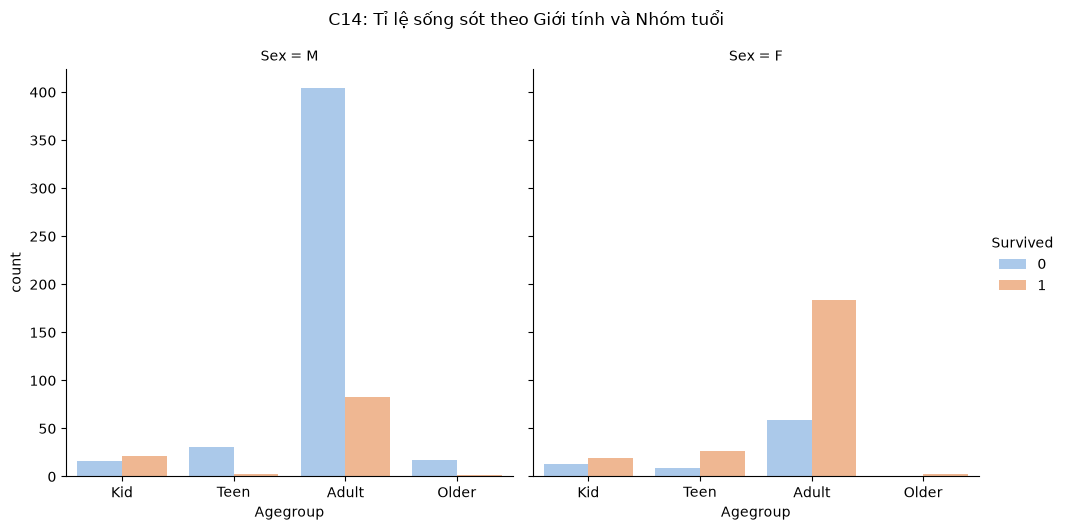


> Nhận xét Câu 14:
  * Ở phía Nam giới (M): Nhóm trẻ em (Kid) có tỷ lệ sống sót khả quan nhất so với các nhóm tuổi còn lại.
  * Ở phía Nữ giới (F): Tỷ lệ sống sót giữ mức cao tuyệt đối ở hầu hết các nhóm tuổi (Kid, Teen, Adult). 
  Điều này phản ánh chính xác quy tắc văn hóa cứu hộ lịch sử trong sự kiện Titanic: "Ưu tiên phụ nữ và trẻ em".

--------------------------------------------------


C:\Users\Admin\AppData\Local\Temp\ipykernel_8756\2710622015.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='familySize', y='Survived', data=titanic_df, ax=axes[0], errorbar=None, palette='magma')
C:\Users\Admin\AppData\Local\Temp\ipykernel_8756\2710622015.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Alone', y='Survived', data=titanic_df, ax=axes[1], errorbar=None, palette='coolwarm')


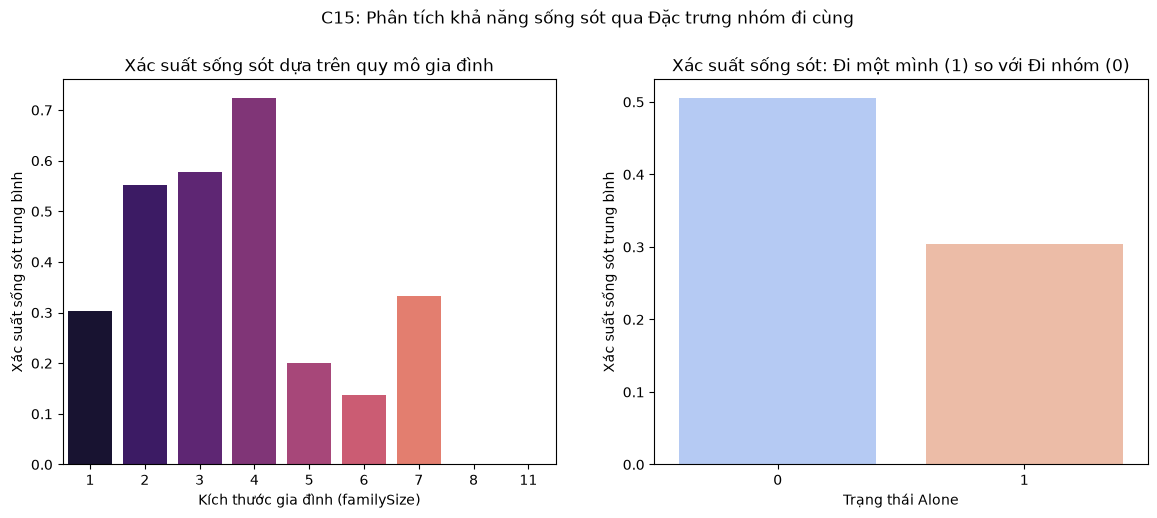


> Nhận xét Câu 15: 
  Hành khách đi một mình (Alone = 1) có cơ hội sống sót thấp hơn hẳn người đi cùng người thân (Alone = 0). 
  Những nhóm gia đình nhỏ có từ 2 đến 4 thành viên sở hữu xác suất sống sót lý tưởng nhất. Ngược lại, nếu số lượng 
  thành viên gia đình quá đông (từ 5 người trở lên), tỷ lệ sống sót sụt giảm nghiêm trọng do sự khó khăn khi 
  tìm kiếm và di chuyển cùng nhau trong hoàn cảnh hoảng loạn.

--------------------------------------------------


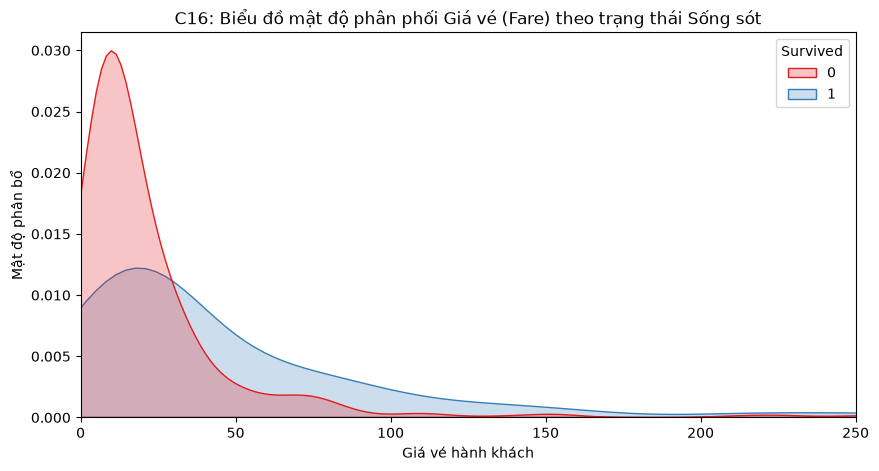


> Nhận xét Câu 16: 
  Đường mật độ chỉ ra nhóm hành khách sở hữu vé giá thấp (vùng cận từ 0 đến 30 đơn vị tiền tệ) có mật độ thiệt mạng 
  (đường màu đỏ) cao đột biến. Khi giá vé tăng tiến dần về phía bên phải, xác suất sống sót của hành khách tăng lên 
  rõ rệt, tương đồng với lợi thế về vị trí tầng boong và quyền ưu tiên của các nhóm hạng vé cao cấp.

--------------------------------------------------


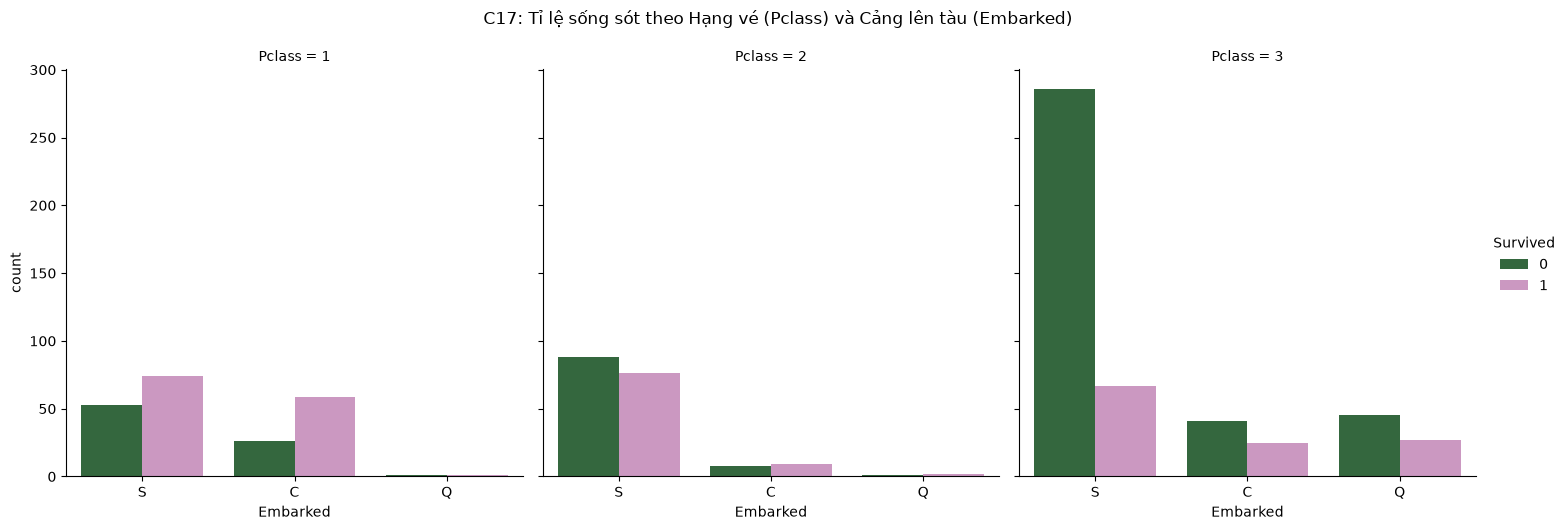


> Nhận xét Câu 17: 
  Cảng S (Southampton) là nơi đón lượng hành khách lớn nhất lên tàu. Điểm đáng chú ý nhất nằm ở phân lớp Hạng 3 (Pclass 3), 
  lượng hành khách xuất phát từ cảng S có số ca tử vong cao kỷ lục trên toàn bộ hệ thống biểu đồ. Trong khi đó, hành khách 
  xuất phát từ cảng C (Cherbourg) ở nhóm Hạng 1 lại ghi nhận tỷ lệ được cứu trợ thành công vượt trội.

--- HOÀN THÀNH TOÀN BỘ BÀI LAB 4 ---


In [3]:
# ==========================================
# LAB 4 - PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA
# ==========================================

# Đảm bảo dữ liệu đã có sẵn từ phần 1
print("--- BẮT ĐẦU QUY TRÌNH KHAI THÁC THÔNG TIN HỮU ÍCH (EDA) ---")

# --- Câu 12: Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', hue='Survived', data=titanic_df, palette='Set1')
plt.title('C12: Tương quan tỉ lệ Sống sót / Thiệt mạng theo Giới tính')
plt.xlabel('Giới tính (M: Nam, F: Nữ)')
plt.ylabel('Số lượng hành khách')
plt.show()

print("""
> Nhận xét Câu 12: 
  Biểu đồ thể hiện rõ rệt sự phân hóa cơ hội sống sót qua giới tính. Tỷ lệ sống sót của Nữ giới (F) vượt trội hoàn toàn 
  so với tỷ lệ thiệt mạng. Ngược lại, đại đa số Nam giới (M) đều không thể sống sót. Giới tính chắc chắn là biến số 
  có trọng số hàng đầu trong mô hình dự đoán hành khách sống sót.
""")
print("-" * 50)


# --- Câu 13: Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Pclass', hue='Survived', data=titanic_df, palette='viridis')
plt.title('C13: Tỉ lệ hành khách Sống sót theo Hạng vé (Pclass)')
plt.xlabel('Hạng hành khách (Pclass)')
plt.ylabel('Số lượng hành khách')
plt.show()

print("""
> Nhận xét Câu 13: 
  Hành khách ở Hạng 1 (Pclass=1) có số lượng sống sót cao hơn số người thiệt mạng (tỷ lệ tốt nhất). Tuy nhiên, 
  ở Hạng 3, số lượng người thiệt mạng chiếm tỷ trọng áp đảo kinh hoàng. Điều này chứng minh điều kiện kinh tế xã hội 
  và vị trí cabin của từng hạng vé ảnh hưởng sâu sắc đến khả năng tiếp cận thuyền cứu hộ.
""")
print("-" * 50)


# --- Câu 14: Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác ---
sns.catplot(x='Agegroup', hue='Survived', col='Sex', data=titanic_df, kind='count', palette='pastel', order=['Kid', 'Teen', 'Adult', 'Older'])
plt.suptitle('C14: Tỉ lệ sống sót theo Giới tính và Nhóm tuổi', y=1.05)
plt.show()

print("""
> Nhận xét Câu 14:
  * Ở phía Nam giới (M): Nhóm trẻ em (Kid) có tỷ lệ sống sót khả quan nhất so với các nhóm tuổi còn lại.
  * Ở phía Nữ giới (F): Tỷ lệ sống sót giữ mức cao tuyệt đối ở hầu hết các nhóm tuổi (Kid, Teen, Adult). 
  Điều này phản ánh chính xác quy tắc văn hóa cứu hộ lịch sử trong sự kiện Titanic: "Ưu tiên phụ nữ và trẻ em".
""")
print("-" * 50)


# --- Câu 15: Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ theo kích thước gia đình
sns.barplot(x='familySize', y='Survived', data=titanic_df, ax=axes[0], errorbar=None, palette='magma')
axes[0].set_title('Xác suất sống sót dựa trên quy mô gia đình')
axes[0].set_xlabel('Kích thước gia đình (familySize)')
axes[0].set_ylabel('Xác suất sống sót trung bình')

# Biểu đồ theo việc đi một mình
sns.barplot(x='Alone', y='Survived', data=titanic_df, ax=axes[1], errorbar=None, palette='coolwarm')
axes[1].set_title('Xác suất sống sót: Đi một mình (1) so với Đi nhóm (0)')
axes[1].set_xlabel('Trạng thái Alone')
axes[1].set_ylabel('Xác suất sống sót trung bình')

plt.suptitle('C15: Phân tích khả năng sống sót qua Đặc trưng nhóm đi cùng', y=1.02)
plt.show()

print("""
> Nhận xét Câu 15: 
  Hành khách đi một mình (Alone = 1) có cơ hội sống sót thấp hơn hẳn người đi cùng người thân (Alone = 0). 
  Những nhóm gia đình nhỏ có từ 2 đến 4 thành viên sở hữu xác suất sống sót lý tưởng nhất. Ngược lại, nếu số lượng 
  thành viên gia đình quá đông (từ 5 người trở lên), tỷ lệ sống sót sụt giảm nghiêm trọng do sự khó khăn khi 
  tìm kiếm và di chuyển cùng nhau trong hoàn cảnh hoảng loạn.
""")
print("-" * 50)


# --- Câu 16: Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé ---
plt.figure(figsize=(10, 5))
sns.kdeplot(data=titanic_df, x='Fare', hue='Survived', fill=True, common_norm=False, palette='Set1')
plt.title('C16: Biểu đồ mật độ phân phối Giá vé (Fare) theo trạng thái Sống sót')
plt.xlabel('Giá vé hành khách')
plt.ylabel('Mật độ phân bổ')
plt.xlim(0, 250) # Giới hạn dải vé phổ biến để biểu đồ trực quan, dễ quan sát
plt.show()

print("""
> Nhận xét Câu 16: 
  Đường mật độ chỉ ra nhóm hành khách sở hữu vé giá thấp (vùng cận từ 0 đến 30 đơn vị tiền tệ) có mật độ thiệt mạng 
  (đường màu đỏ) cao đột biến. Khi giá vé tăng tiến dần về phía bên phải, xác suất sống sót của hành khách tăng lên 
  rõ rệt, tương đồng với lợi thế về vị trí tầng boong và quyền ưu tiên của các nhóm hạng vé cao cấp.
""")
print("-" * 50)


# --- Câu 17: Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và cảng sẽ cập bến ---
sns.catplot(x='Embarked', hue='Survived', col='Pclass', data=titanic_df, kind='count', palette='cubehelix')
plt.suptitle('C17: Tỉ lệ sống sót theo Hạng vé (Pclass) và Cảng lên tàu (Embarked)', y=1.05)
plt.show()

print("""
> Nhận xét Câu 17: 
  Cảng S (Southampton) là nơi đón lượng hành khách lớn nhất lên tàu. Điểm đáng chú ý nhất nằm ở phân lớp Hạng 3 (Pclass 3), 
  lượng hành khách xuất phát từ cảng S có số ca tử vong cao kỷ lục trên toàn bộ hệ thống biểu đồ. Trong khi đó, hành khách 
  xuất phát từ cảng C (Cherbourg) ở nhóm Hạng 1 lại ghi nhận tỷ lệ được cứu trợ thành công vượt trội.
""")
print("--- HOÀN THÀNH TOÀN BỘ BÀI LAB 4 ---")